### Independent Component Analysis:
- ICA is a technique used to seperate mixed signals into their independent, non-Gaussian components.
- Its aim to find a linear transformation of data that maximizes statistical independence among the components.
- ICA is mainly used in fields like audio, image processing and biomedical signal analysis to isolate distinct sources from mixed signals
### Statistical Independence Concept:
- It refers to the idea that two random variables: X and Y are independent if knowing one does not affect the probability of the other.
- Mathematically, this means the joint probability of X and Y is equal to the product of their individual probabilities.
- P(X and Y) = P(X) * P(Y) or P(X ∩ Y) = P(X)*P(Y)
#### Assumptions in ICA:
- ICA operates under two key assumptions:
  1. The source signals are statistically independent of each other.
  2. The source signals have non-Gaussian distributions.
- These assumptions allow ICA to effectively seperate mixed signals into independent components, a task that traditional methods like PCA cannot achieve.

### Mathematical Representation of ICA:
- The observed random vector is X=(x1,x2,....xm)^T representing the observed data with m components.
- The hidden components are represented by random vector s=(s1,s2...sn)^T where n is the number of hidden sources.
- The observed data X is transformed into hidden components S using a linear static transformation representation by the matrix W.
  - S=WX
- The goal is to transform the observed data X in a way that resulting hidden components are independent.The independence is measured by some function F(s1,....sn).
- The task is to find the optimal transform matrix W that maximizes the independence of hidden components.

### Implementation of ICA:
#### 1. Importing Libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt


#### 2. Generate Random Data and Mix the Signals:
- In this step we can create three seperate signals: a sine wave, a square wave and random noise.
- These represnt different types of real-world signals.
- We use Numpy to generate 200 time points between 0 and 8.
  - signal_1 - A sine wave like a tuning fork tone.
  - signal_2 - A square wave like a digital signal(on/off).
  - signal_3 - A ra ndom noise signal using the Laplace distribution which has sharper peaks than normal distribution.
  - np.c_[] - Combine all three 1D signals into a single 2D array.
  - 0.2 - is the standard deviation of the noise.

In [2]:
np.random.seed(42)
samples = 200
time = np.linspace(0, 8, samples)

signal_1 = np.sin(2 * time)
signal_2 = np.sign(np.sin(3 * time))
signal_3 = np.random.laplace(size=samples)

S = np.c_[signal_1, signal_2, signal_3]
S +=0.2 * np.random.normal(size=S.shape)

A = np.array([[1,1,1],[0.5,2,1],[1.5,1,2]])
X = S.dot(A.T)

#### 3. Apply ICA to unmix the signals:
- FastICa is a specific implementation of the Independent Component Analysis(ICA) algorithm that is designed for efficiency and speed.
- In this step we apply Independent Component Analysis using the FastICA class from Scikit-learn.
- We first create an instance of FastICA and set the number of independent components to 3 matching the number of original signals.

In [5]:
from sklearn.decomposition import FastICA
ica = FastICA(n_components =3)
s_ica = ica.fit_transform(X)

#### 4. Visualizing the signals:
- In this step we use Matplotlib to plot and compare the original sources, mixed signals and the signals recovered using ICA.
- We create three subplots:
  1. First shows the original synthetic signals.
  2. Second shows the observed mixed signals.
  3. Third shoes the estimated independent sources obtained from ICA.

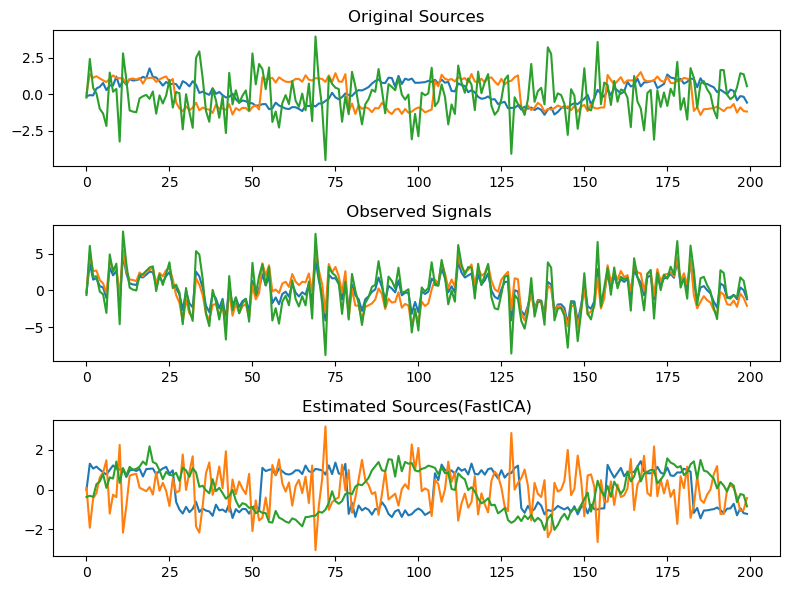

In [7]:
plt.figure(figsize=(8,6))

plt.subplot(3,1,1)
plt.title('Original Sources')
plt.plot(S)

plt.subplot(3,1,2)
plt.title(' Observed Signals')
plt.plot(X)

plt.subplot(3,1,3)
plt.title('Estimated Sources(FastICA)')
plt.plot(s_ica)

plt.tight_layout()
plt.show()

### Difference between PCA and ICA:
#### PCA:
- Goal - Reduces the dimensons to avoid the problem of overfitting.
- Types of Components - Deals with the principal components.
- Focus on variance - Focus on maximizing the variance.
- Orthogonality - Focuses on the mutual orthogonality property of the principal components.
- Independence - Don't focus on the mutual independence of the coponents.
- Typical Use - Mainly used for dimensionality reduction.

#### ICA:
- Goal - Decomposes the mixed signal into its independent source signals.
- Types of Components - Deals with Independence Components.
- Focus on variance - Doesn't focus on the issue of variance among the data points.
- Orthogonality - Doesn't focus on the mutual orthogonality property of the components.
- Independence - Focuses on the mutual independence of the components.
- Typical Use - Mainly used for signal seperation and feature extraction.